In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.rc("font", family = "Malgun Gothic")
sns.set(font="Malgun Gothic", 
rc={"axes.unicode_minus":False}, style='white')

# # 한글 폰트 설정 (Mac)
# plt.rc('font', family='AppleGothic')
# # 마이너스 기호 깨짐 방지
# plt.rcParams['axes.unicode_minus'] = False


In [6]:
gangwon_industry = pd.read_csv('./data/merge_file_gangwon/산업용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_industry = gangwon_industry.rename({'전력량':'전력사용량'},axis=1)
gangwon_industry = gangwon_industry[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력사용량','HDD','CDD']]

In [7]:

cor_columns = gangwon_industry[['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)','전력사용량','HDD','CDD']]


test  = cor_columns.corr()['전력사용량'].sort_values(ascending=False).reset_index()
# sns.heatmap(
#         test.T,          # 1행 x 10열
#         annot=True, fmt=".2f",
#         cmap='coolwarm',
#         vmin=-1, vmax=1,
#         cbar_kws={'label':'상관계수'}
#     )

In [8]:
test.rename(columns={'index': '기온별'}, inplace=True)
test

,기온별,전력사용량
0,전력사용량,1.000000
1,평균풍속(m/s),0.281248
2,평균현지기압(hPa),0.178885
3,평균기온(°C),0.077622
4,평균지면온도(°C),0.052281
5,일조율(%),0.035709
6,평균수증기압(hPa),0.019602
7,CDD,-0.013728
8,월합강수량(00~24h만)(mm),-0.026956
9,최심적설(cm),-0.039525


Text(0.5, 1.0, '강원도(산업용)의 전력사용량과 기상요인 상관계수')

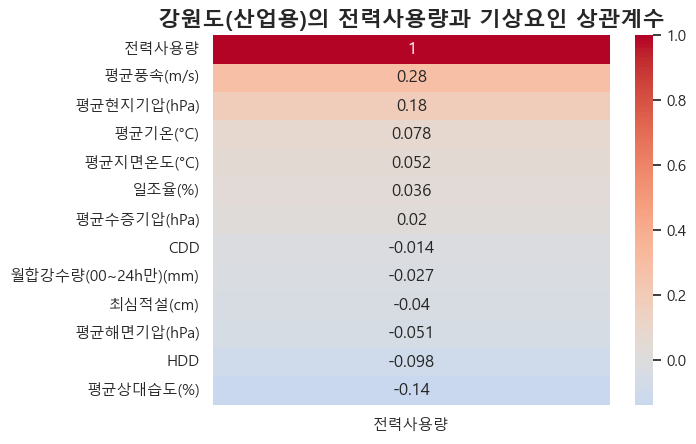

In [10]:
sns.heatmap(
    test[['전력사용량']],
    annot=True,
    cmap='coolwarm',
    center=0,
    yticklabels=test['기온별']   # 🔥 여기
)
plt.title('강원도(산업용)의 전력사용량과 기상요인 상관계수',fontweight='bold', fontsize=16)